In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. CRIAÇÃO DO DATASET

Criamos um conjunto de dados 2D em formato de duas "meias-luas".

O parâmetro `noise` adiciona ruído aos dados, tornando o problema
um pouco mais realista.

In [27]:
X, y = make_moons(
    n_samples=200,  # Número de amostras a serem geradas no dataset
    noise=0.35,     # Desvio padrão de ruído gaussiano adicionado aos dados
    random_state=42 # Semente aleatória para reprodutibilidade
)

# 2. SEPARAÇÃO ENTRE TREINO E TESTE

**IMPORTANTE:**

O modelo NÃO verá os dados de teste durante o treinamento.

- 80% dos dados para treinamento
- 20% dos dados para teste

Dessa forma, conseguimos verificar se o modelo realmente aprendeu
ou simplesmente decorou os exemplos utilizados no treinamento.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, # Features do dataset
    y, # Labels (rótulos) do dataset
    test_size=0.20, # 20% dos dados serão usados para teste
    random_state=42, # Semente aleatória para reprodutibilidade da divisão
    stratify=y # Garante que as proporções de classes sejam mantidas nos conjuntos de treino e teste
)

# 3. CRIAÇÃO DOS MODELOS

## Modelo Equilibrado (clf_suave)

Árvore com profundidade limitada (`max_depth=3`). A ideia é impedir que a árvore crie regras extremamente específicas para cada ponto de treinamento, promovendo a generalização.

## Modelo Complexo (clf_overfit)

Árvore muito mais complexa (`max_depth=15`). Esta árvore pode criar diversas regras para tentar classificar corretamente praticamente todos os pontos do conjunto de treinamento, o que pode levar ao overfitting.

In [21]:
clf_suave = DecisionTreeClassifier(
    max_depth=3,    # Profundidade máxima da árvore para evitar overfitting
    random_state=42 # Semente aleatória para reprodutibilidade do modelo
)

clf_overfit = DecisionTreeClassifier(
    max_depth=15,   # Profundidade máxima da árvore, um valor alto que pode causar overfitting
    min_samples_split=2, # Número mínimo de amostras necessárias para dividir um nó interno
    random_state=42 # Semente aleatória para reprodutibilidade do modelo
)

# 4. TREINAMENTO DOS MODELOS

Ambos os modelos são treinados usando apenas o conjunto de dados de treinamento (`X_train`, `y_train`).

In [22]:
clf_suave.fit(X_train, y_train) # Treina o modelo suave com os dados de treinamento
clf_overfit.fit(X_train, y_train) # Treina o modelo com possível overfitting com os dados de treinamento

DecisionTreeClassifier(max_depth=15, random_state=42)

# 5. AVALIAÇÃO DOS MODELOS

Avaliamos a acurácia de cada modelo tanto no conjunto de treinamento quanto no conjunto de teste para entender como eles generalizam para dados não vistos.

In [23]:
acc_suave_treino = accuracy_score(
    y_train, # Rótulos verdadeiros do conjunto de treinamento
    clf_suave.predict(X_train) # Previsões do modelo suave no conjunto de treinamento
)

acc_suave_teste = accuracy_score(
    y_test, # Rótulos verdadeiros do conjunto de teste
    clf_suave.predict(X_test) # Previsões do modelo suave no conjunto de teste
)

acc_overfit_treino = accuracy_score(
    y_train, # Rótulos verdadeiros do conjunto de treinamento
    clf_overfit.predict(X_train) # Previsões do modelo com overfitting no conjunto de treinamento
)

acc_overfit_teste = accuracy_score(
    y_test, # Rótulos verdadeiros do conjunto de teste
    clf_overfit.predict(X_test) # Previsões do modelo com overfitting no conjunto de teste
)

# 6. FUNÇÃO PARA DESENHAR A FRONTEIRA DE DECISÃO

Esta função auxiliar visualiza a fronteira de decisão de um classificador, mostrando como ele divide o espaço das features para classificar os pontos. Inclui pontos de treinamento e teste para comparação.

In [24]:
def plotar_fronteira(
    clf,
    X_train,
    y_train,
    X_test,
    y_test,
    titulo,
    ax
):

    # Limites do gráfico
    x_min = X_train[:, 0].min() - 0.5
    x_max = X_train[:, 0].max() + 0.5

    y_min = X_train[:, 1].min() - 0.5
    y_max = X_train[:, 1].max() + 0.5

    # Criamos uma grade de pontos para desenhar
    # a região de decisão do modelo.
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Fazemos a previsão para cada ponto da grade.
    Z = clf.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    # Desenha as regiões classificadas pelo modelo.
    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap="coolwarm"
    )

    # DADOS DE TREINAMENTO
    ax.scatter(
        X_train[y_train == 0, 0],
        X_train[y_train == 0, 1],
        c="blue",
        edgecolors="k",
        label="Treino - Classe 0"
    )

    ax.scatter(
        X_train[y_train == 1, 0],
        X_train[y_train == 1, 1],
        c="red",
        edgecolors="k",
        label="Treino - Classe 1"
    )

    # DADOS DE TESTE
    # Utilizamos um marcador diferente para deixar claro que esses
    # pontos não participaram do treinamento.
    ax.scatter(
        X_test[y_test == 0, 0],
        X_test[y_test == 0, 1],
        c="blue",
        edgecolors="black",
        marker="X",
        s=100,
        label="Teste - Classe 0"
    )

    ax.scatter(
        X_test[y_test == 1, 0],
        X_test[y_test == 1, 1],
        c="red",
        edgecolors="black",
        marker="X",
        s=100,
        label="Teste - Classe 1"
    )

    ax.set_title(
        titulo,
        fontsize=12,
        fontweight="bold"
    )

    ax.grid(
        True,
        linestyle="--",
        alpha=0.4
    )

    ax.legend(
        loc="upper right",
        fontsize=8
    )

# 7. VISUALIZAÇÃO DAS FRONTEIRAS DE DECISÃO

Comparamos visualmente as fronteiras de decisão dos dois modelos:

- O Modelo Equilibrado (`clf_suave`) com `max_depth=3`.
- O Modelo Complexo (`clf_overfit`) com `max_depth=15`.

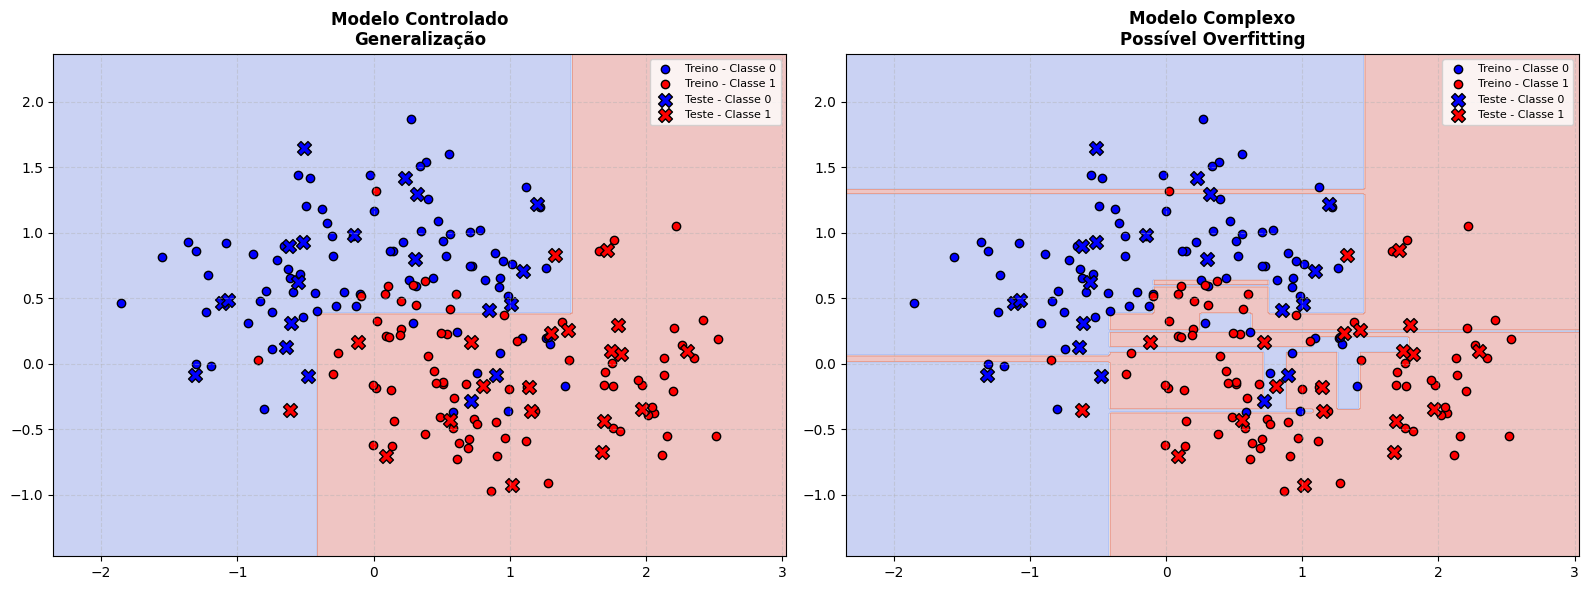

In [25]:
fig, axes = plt.subplots(
    1, # Uma linha para os subplots
    2, # Duas colunas para os subplots (um para cada modelo)
    figsize=(16, 6) # Define o tamanho total da figura
)


plotar_fronteira(
    clf_suave, # Modelo DecisionTreeClassifier suave
    X_train,   # Dados de treinamento
    y_train,   # Rótulos de treinamento
    X_test,    # Dados de teste
    y_test,    # Rótulos de teste
    "Modelo Controlado\nGeneralização", # Título do subplot do modelo suave
    axes[0]    # Eixo para plotar o modelo suave
)


plotar_fronteira(
    clf_overfit, # Modelo DecisionTreeClassifier com overfitting
    X_train,     # Dados de treinamento
    y_train,     # Rótulos de treinamento
    X_test,      # Dados de teste
    y_test,      # Rótulos de teste
    "Modelo Complexo\nPossível Overfitting", # Título do subplot do modelo com overfitting
    axes[1]      # Eixo para plotar o modelo com overfitting
)


plt.tight_layout() # Ajusta automaticamente os parâmetros do subplot para que caibam na área da figura
plt.show() # Exibe a figura

# 8. RESULTADOS E INTERPRETAÇÃO

Analisamos as acurácias de treinamento e teste para ambos os modelos, destacando a diferença entre o desempenho esperado de um modelo que generaliza bem e um modelo que sofre de overfitting.

In [26]:
print("=" * 60)
print("RESULTADOS")
print("=" * 60)

print("\nMODELO CONTROLADO")
print(
    f"Acurácia no treino: {acc_suave_treino * 100:.1f}%"
)
print(
    f"Acurácia no teste : {acc_suave_teste * 100:.1f}%"
)

print("\nMODELO COM OVERFITTING")
print(
    f"Acurácia no treino: {acc_overfit_treino * 100:.1f}%"
)
print(
    f"Acurácia no teste : {acc_overfit_teste * 100:.1f}%"
)

print("\n" + "=" * 60)
print("INTERPRETAÇÃO")
print("=" * 60)

print("""
Um modelo com overfitting pode apresentar uma acurácia muito alta
no conjunto de treinamento porque aprendeu características muito
específicas daqueles exemplos.

O problema aparece quando avaliamos o modelo em dados de teste,
que ele nunca viu durante o treinamento.

A diferença entre o desempenho no treino e no teste é um dos sinais
que podemos observar para identificar possíveis problemas de
generalização.
""")

RESULTADOS

MODELO CONTROLADO
Acurácia no treino: 86.2%
Acurácia no teste : 90.0%

MODELO COM OVERFITTING
Acurácia no treino: 100.0%
Acurácia no teste : 82.5%

INTERPRETAÇÃO

Um modelo com overfitting pode apresentar uma acurácia muito alta
no conjunto de treinamento porque aprendeu características muito
específicas daqueles exemplos.

O problema aparece quando avaliamos o modelo em dados de teste,
que ele nunca viu durante o treinamento.

A diferença entre o desempenho no treino e no teste é um dos sinais
que podemos observar para identificar possíveis problemas de
generalização.

